# Bank Customer Churn — Exploratory Data Analysis


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

In [ ]:
df=pd.read_csv("Bank_Customer_Churn_Dataset_Abhishek_Chauhan.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Data Cleaning

Dropping identifier columns (`RowNumber`, `CustomerId`, `Surname`) since they have no predictive value for churn.

In [3]:
df.drop(columns=["RowNumber"],inplace=True)

df.shape

(10000, 13)

In [4]:
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='str')

In [5]:
df.drop(columns=['CustomerId', 'Surname'],inplace=True)

## 4. Dataset Overview

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 966.1 KB


In [7]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## 5. Categorical & Numerical Columns

In [9]:
categorical_cols=['Geography', 'Gender','HasCrCard','IsActiveMember','Exited']

numerical_cols=['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts','EstimatedSalary']


In [10]:
for cat_col in categorical_cols:
    print(df[cat_col].value_counts(),end="\n\n")
    print(df[cat_col].value_counts(normalize=True)*100,end="\n\n")
    print("*"*100)

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64

****************************************************************************************************
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64

****************************************************************************************************
HasCrCard
1    7055
0    2945
Name: count, dtype: int64

HasCrCard
1    70.55
0    29.45
Name: proportion, dtype: float64

****************************************************************************************************
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

IsActiveMember
1    51.51
0    48.49
Name: proportion, dtype: float64

****************************************************************************************************
Exited
0    7963
1    2

## 6. Check for Duplicates

In [11]:
df.duplicated().sum()  #0 duplicates

np.int64(0)

In [12]:
#categorical_cols=['Geography', 'Gender','HasCrCard','IsActiveMember','Exited']

#numerical_cols=['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts','EstimatedSalary']


## 7. Target Variable Distribution (Exited)

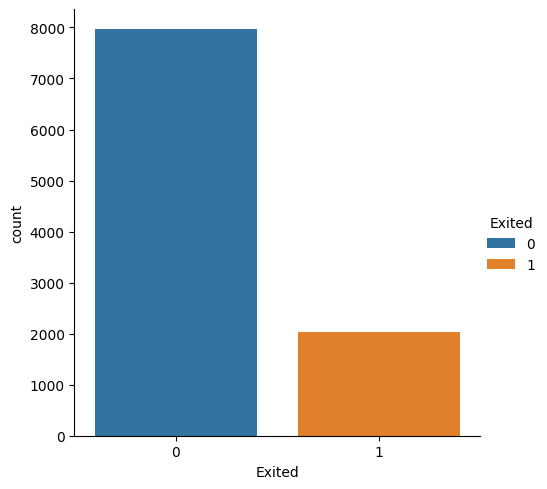

In [13]:
sns.catplot(x="Exited",kind="count",hue="Exited",data=df)

In [14]:
sns.set_style("whitegrid")

## 8. Numerical Features vs Churn (Violin Plots)

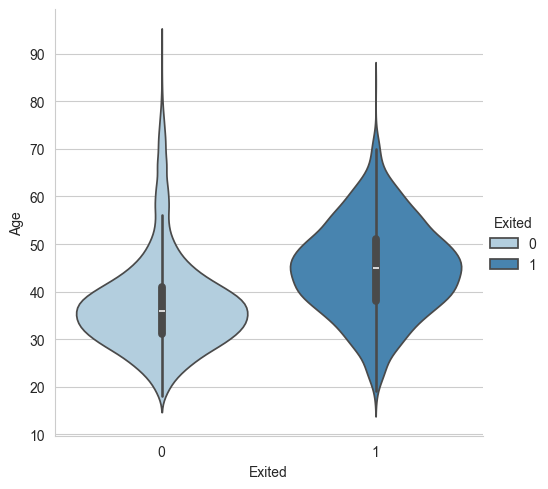

In [15]:
sns.catplot(x="Exited",y="Age",kind="violin",hue="Exited",palette="Blues",data=df)

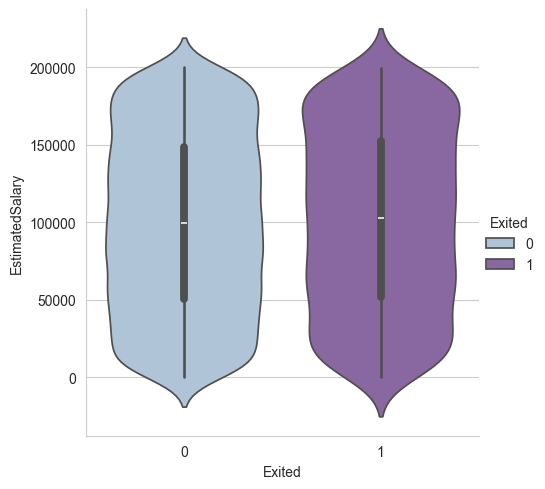

In [16]:
sns.catplot(x="Exited",y="EstimatedSalary",kind="violin",hue="Exited",palette="BuPu",data=df)

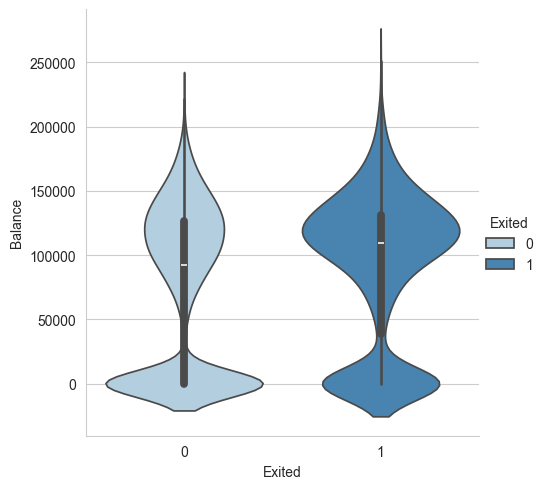

In [17]:
sns.catplot(x="Exited",y="Balance",kind="violin",hue="Exited",palette="Blues",data=df)

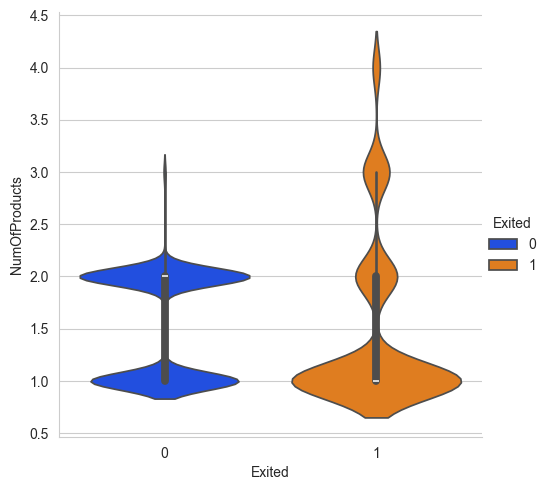

In [18]:
sns.catplot(x="Exited",y="NumOfProducts",kind="violin",hue="Exited",palette="bright",data=df)

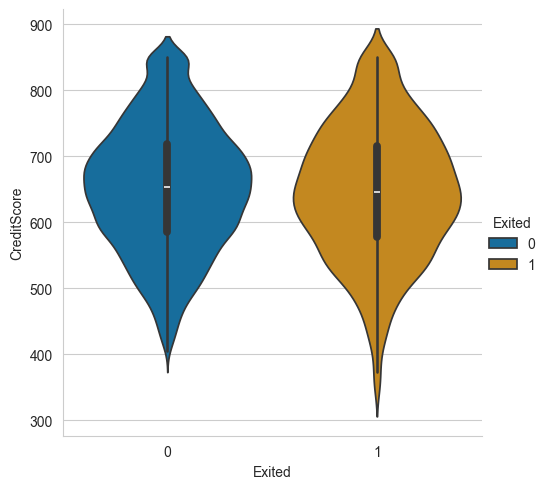

In [19]:
sns.catplot(x="Exited",y="CreditScore",kind="violin",hue="Exited",palette="colorblind",data=df)

## 9. Categorical Features vs Churn (Count Plots)

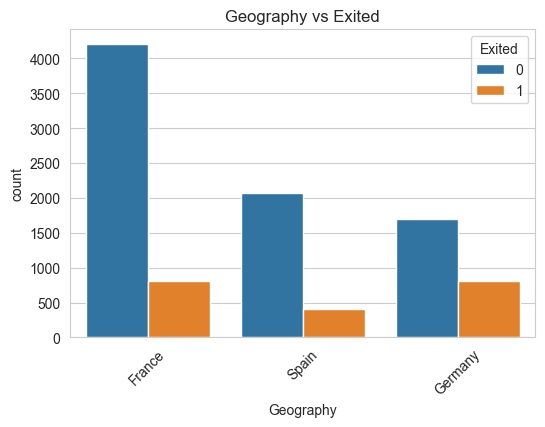

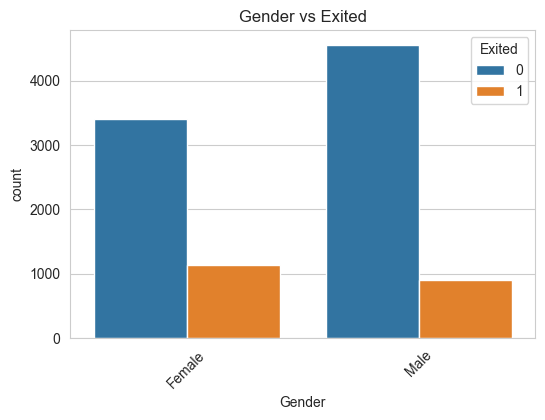

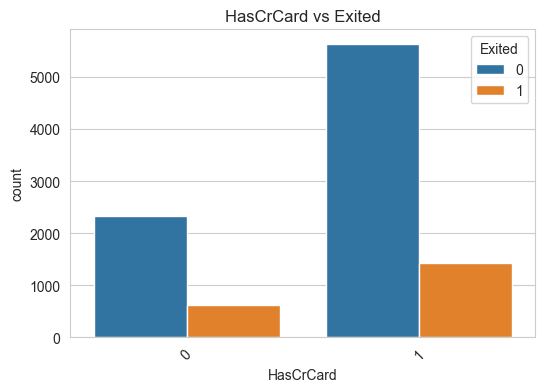

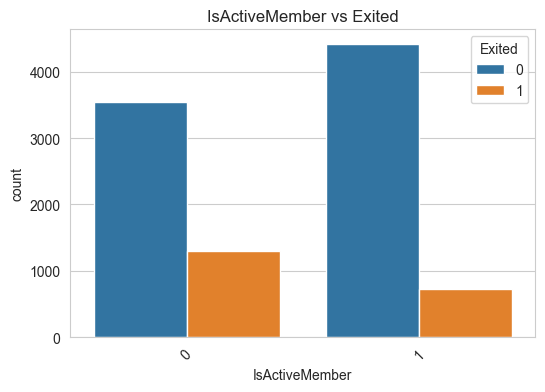

In [20]:
for col in categorical_cols:
    if col!="Exited":
        plt.figure(figsize=(6,4))
        sns.countplot(x=col, hue='Exited', data=df)
        plt.title(f"{col} vs Exited")
        plt.xticks(rotation=45)
        plt.show()


## 10. Geography, Gender & Other Categorical Breakdown vs Churn

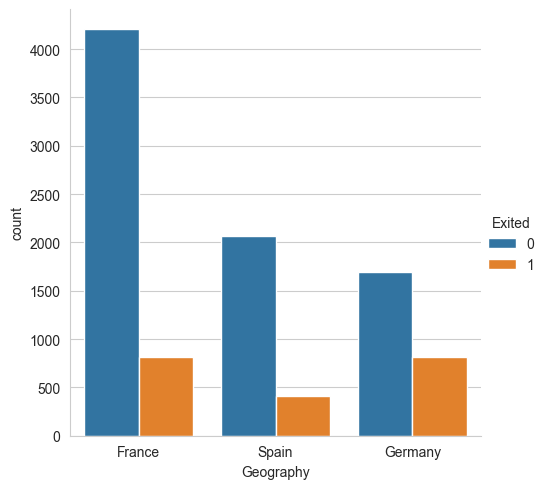

In [21]:
sns.catplot(x="Geography",kind="count",hue="Exited",data=df)

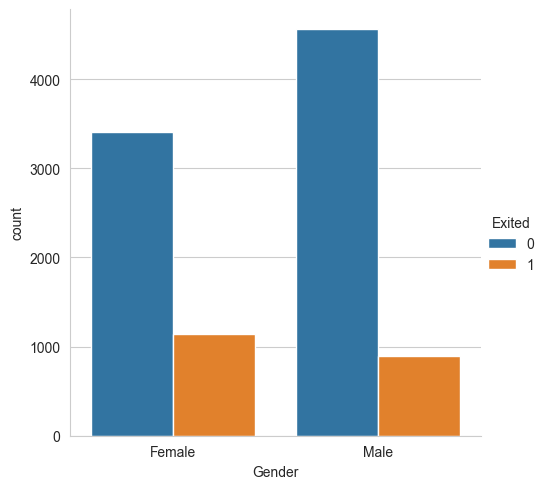

In [22]:
sns.catplot(x="Gender",kind="count",hue="Exited",data=df)

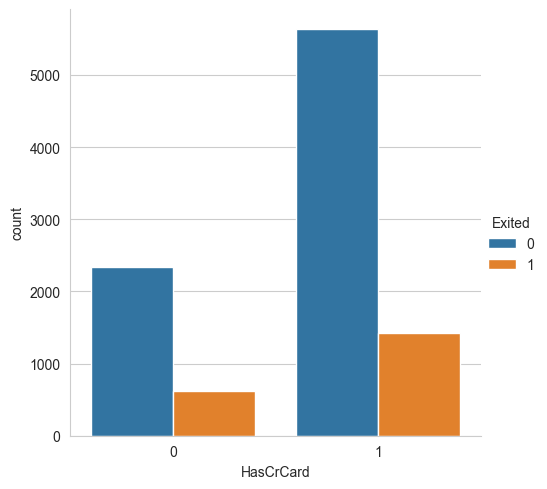

In [23]:
sns.catplot(x="HasCrCard",kind="count",hue="Exited",data=df)

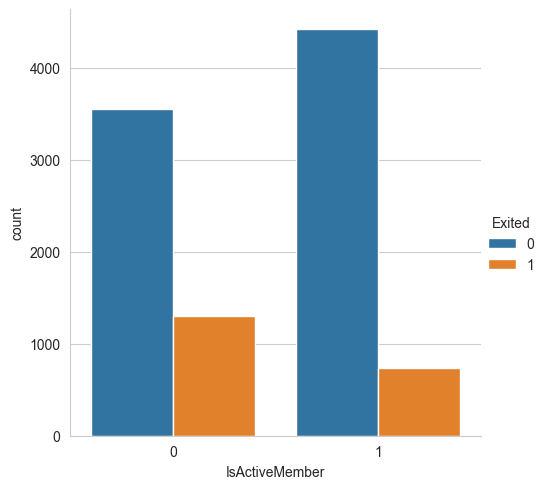

In [24]:
sns.catplot(x="IsActiveMember",kind="count",hue="Exited",data=df)

## 11. Numerical Features vs Churn (Bar Plots)

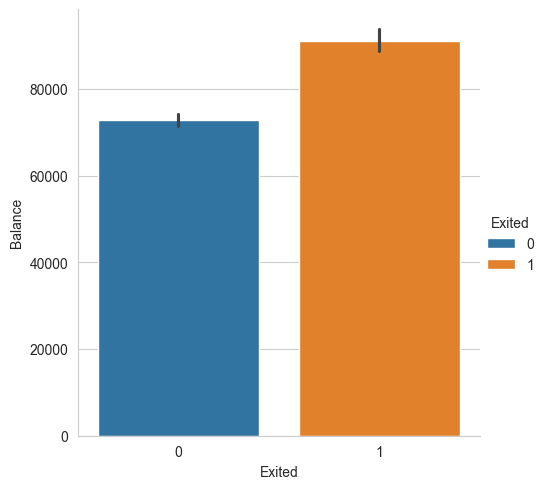

In [25]:
sns.catplot(x="Exited",y="Balance",kind="bar",hue="Exited",data=df)

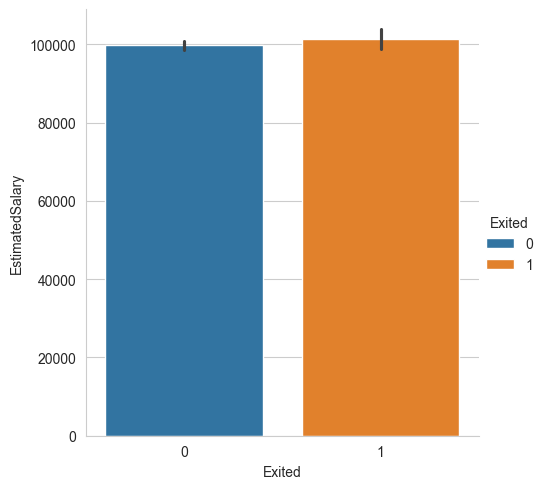

In [26]:
sns.catplot(x="Exited",y="EstimatedSalary",kind="bar",hue="Exited",data=df)

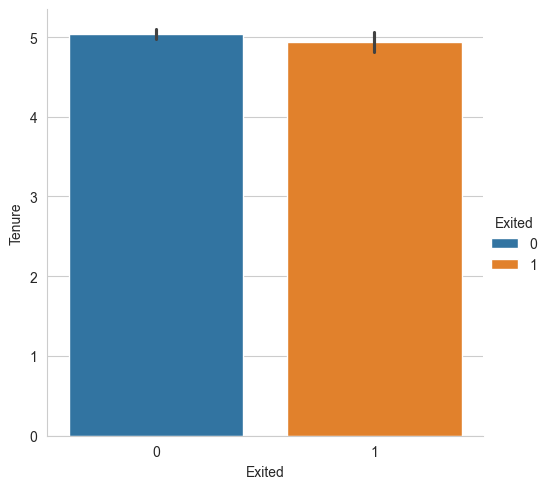

In [27]:
sns.catplot(x="Exited",y="Tenure",kind="bar",hue="Exited",data=df)

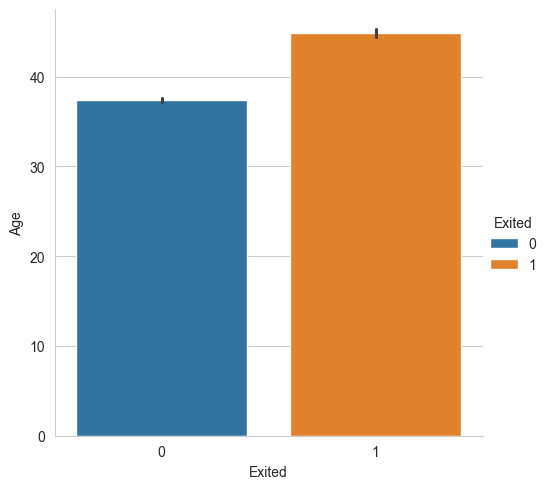

In [28]:
sns.catplot(x="Exited",y="Age",kind="bar",hue="Exited",data=df)

## 12. Save Cleaned Dataset

In [29]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.to_csv("Cleaned_Bank_Customer_Churn_Dataset_Abhishek_Chauhan.csv",index=False)
print("Cleaned datset saved")

Cleaned datset saved


## Key Takeaways

- Overall churn rate is about **20.4%** (2,037 out of 10,000 customers).
- **Germany** has the highest churn rate (~32%) compared to France and Spain (~16-17% each).
- **Older customers** churn more — average age of churned customers (~45) is higher than retained customers (~37).
- **Inactive members** churn more than active members (~27% vs ~14%).
- Customers with **3 or 4 products** churn at a very high rate (83% and 100%), while those with 1-2 products churn much less.
- **Female customers** churn somewhat more than male customers (~25% vs ~16%).
- `HasCrCard` shows almost no difference in churn rate, so it's likely a weak predictor.
- `Age` and `IsActiveMember` show the strongest correlation with churn among numerical features.
